<a href="https://colab.research.google.com/github/UNICAMP-EA979/2026s1-projetopi-e2-Patricio-Andre-1/blob/main/Atividade.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projeto PI
### André Patricio de Sousa
### RA: 260363

# Escopo do Projeto
Queremos estudar como diferentes modelos conseguem lidar com o problema de classificação das imagens em seus possíveis grupos de efeitos. Para isso, vamos usar diferentes algorítmos, supervisionados e não supervisionados, mostrando vantagens e desvantagens de cada um dos métodos para a realização da tarefa.

### Imports
Primeiro é importante definir quais bibliotecas serão necessárias para realizar as tarefas que necessitamos. Junto à isso, vamos permitir que os sistemas sejam treinados usando CUDA para maior velocidade nos treinamentos através do uso de processamento paralelo de GPU's.

In [35]:
# 1. Bibliotecas Padrão e Sistema
import os
import io
import time
import shutil
import random
import zipfile
from glob import glob
from types import SimpleNamespace
from tqdm.auto import tqdm

# 2. Manipulação de Dados e Visualização
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

# 3. PyTorch (Core, Dados e Visão)
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset, TensorDataset
import torchvision.transforms as T
from torchvision.utils import make_grid
from torchvision.datasets import ImageFolder
import torchvision.models as models

# 4. PyTorch Lightning e Métricas
!pip install -q pytorch-lightning torchmetrics
import pytorch_lightning as pl
from torchmetrics import Accuracy

# 5. Scikit-learn (Machine Learning Clássico, EDA e Avaliação)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import train_test_split

# 6. UMAP (Redução de Dimensionalidade)
# Tenta importar; se não existir, instala automaticamente no Colab
try:
    import umap
except ImportError:
    print("Instalando a biblioteca UMAP")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "umap-learn"])
    import umap


# CONFIGURAÇÃO GERAL E GPU
# Aqui decidimos usar cuda se estiver disponível
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Ambiente configurado com sucesso! Dispositivo em uso: {device}")

Ambiente configurado com sucesso! Dispositivo em uso: cuda


# Extração dos dados
Usamos essa etapa para lidar com os arquivos e conferimos ao fim os nomes das pastas, que nesse caso serão as classes que queremos estudar e que futuramente serão os rótulos que usaremos para classificar cada indivíduo.   
O primeiro problema, que será comentado em diversos trechos desse trabalho é que as classes não estão muito bem definidas uma vez que classes diferentes são geradas pelo mesmo efeito gerando a ilusão de termos 42 classes quando na verdades temos menos classes.   
Os efeitos são gerados por pessoas diferentes mas na prática tem implementação muito parecidas e por isso serão um desafio a mais para nossos modelos.

In [5]:
import os
import zipfile
from google.colab import drive

# 1. Montar Google Drive
try:
    drive.mount('/content/drive')
except:
    print("Aviso: Google Drive não montado ou já estava conectado.")

# Definimos os caminhos
zip_path_drive = '/content/drive/MyDrive/dataset.zip'
base_folder = 'photos'

if os.path.exists(zip_path_drive):
    # Só extrai se a pasta base ainda não existir (evita extrair duas vezes à toa)
    if not os.path.exists(base_folder):
        print(f"Extraindo {zip_path_drive} para '{base_folder}'")
        with zipfile.ZipFile(zip_path_drive, 'r') as zip_ref:
            zip_ref.extractall(base_folder)
        print("Extração concluída!")
    else:
        print("A pasta já existe. Pulando a extração para economizar tempo.")
else:
    print(f"Erro: O arquivo '{zip_path_drive}' não foi encontrado.")

# Verifica se existe a subpasta 'dataset' criada pelo zip
if os.path.exists(os.path.join(base_folder, 'dataset')):
    data_dir = os.path.join(base_folder, 'dataset')
else:
    data_dir = base_folder

# Lista as pastas reais (efeitos)
if os.path.exists(data_dir):
    classes = [d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))]
    print(f"\nTotal de efeitos detectados: {len(classes)}")
    print(f"Classes (Efeitos): {classes[:10]} ... [truncado para leitura]")
else:
    print(f"Erro: O diretório '{data_dir}' não foi encontrado mesmo após a tentativa de extração.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
A pasta já existe. Pulando a extração para economizar tempo.

Total de efeitos detectados: 42
Classes (Efeitos): ['247145_border_detection', '243360_radial_blur', '257234_industrial_effect', '241163_pixelation', '297611_green_railing_dither', '245609_borda_lapis', '260382_difference_of_gaussians_flow', '247145_color_selection', '245760_dithering', '260382_delete_later'] ... [truncado para leitura]


### Dataloaders
Aqui definimos as imagens para um novo tamanho: 224 x 224, visando aumentar a performance do modelo escolhido posteriormente: Resnet18.

Construímos então nosso Dataset a partir das imagens que transformamos no processo

Definimos nosso dataloader com batch_size de 32 a partir do nosso dataset e mostramos alguns dos integrantes na saída.

Construindo o Dataset PyTorch...
Puxando o primeiro lote de imagens...


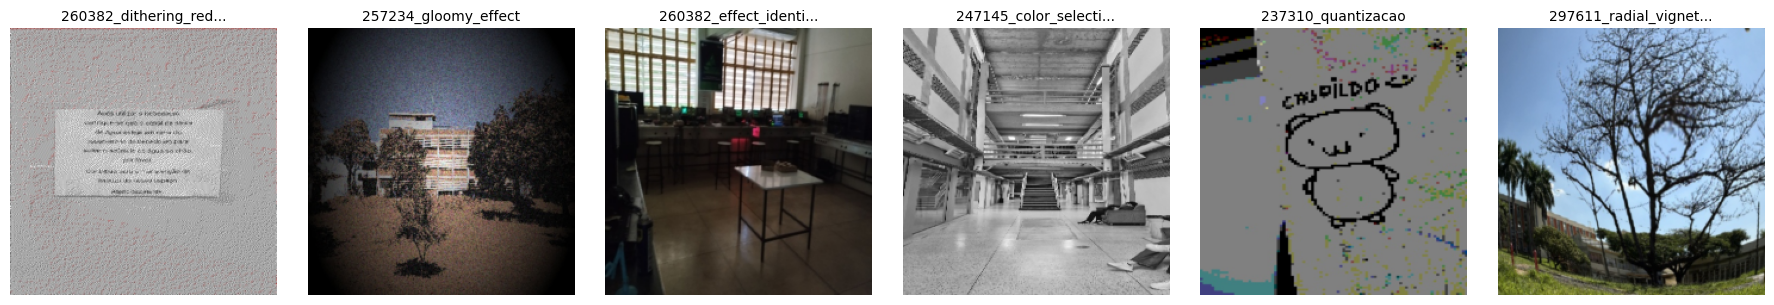

In [36]:
transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor()
])

print("Construindo o Dataset PyTorch...")
try:
    dataset = ImageFolder(root=data_dir, transform=transform)
    classes = dataset.classes

    dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

    print("Puxando o primeiro lote de imagens...")
    images, labels = next(iter(dataloader))

    fig, axes = plt.subplots(1, 6, figsize=(18, 3))
    for i in range(6):
        img_plot = images[i].numpy().transpose((1, 2, 0))
        axes[i].imshow(img_plot)
        titulo = classes[labels[i].item()]
        axes[i].set_title(titulo[:20] + "..." if len(titulo) > 20 else titulo, fontsize=10)
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Ocorreu um erro no PyTorch: {e}")

# Caso não-supervisionado
### PCA - Análise de componentes principais
Usando PCA para a nossa aplicação, queremos agrupar os dados de tal forma que a partir de um gráfico seja possível ver claramente uma separação entre eles, criar grupos. Para isso o PCA, que é uma transformação linear, faz uma mudança de base assumindo que a direção em que os dados apresentam maior variância revela a importância da informação.

Esse algorítmo é simples, rápido e consegue lidar com diversos problemas de classificação quando as features já foram extraídas. No nosso caso, houve já essa extração por um modelo extremamente competente.

Entretanto, o PCA sozinho não é suficiente para classificar tão bem os dadosconsiderando os 512 filtros que temos acesso. Ele é um algoritmo que só consegue trabalhar com rotações e ao traçar hiperplanos faz a divisão entre os dados.

### t-SNE (t-Distributed Stochastic Neighbor Embedding)
Enquanto isso, o t-SNE é um algoritmo de aprendizado de manifold que não é linear. Ele transforma a distância entre em probabilidades e resolve um problema de otimização.

Para conseguir desdobrar corretametne esse manifold o t-SNE consegue mapear mesmo relações não lineares complicadas. Com isso, ele vem acompanhado de um maior custo computacional. A função que rege o algorítmo também não é convexa, resultando em diferentes saídas a cada execução, sendo este um algorítmo estocástico.

In [8]:

print("Carregando modelo ResNet18 para extrair as características das imagens...")

# Carrega a rede pré-treinada e remove a última camada (que seria de classificação)
# Assim, ela nos devolve os 'features' puros (512 números por imagem)
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
resnet.fc = nn.Identity()
resnet = resnet.to(device)
resnet.eval() # Modo de avaliação (não vamos treinar ela agora)

features_list = []
labels_list = []

print("Passando as quase 8 mil imagens pela rede")
# Desativa o cálculo de gradientes para economizar memória e ficar mais rápido
with torch.no_grad():
    for images, targets in tqdm(dataloader, desc="Extraindo Features"):
        images = images.to(device)

        # Passa as imagens pela rede
        output = resnet(images)

        # Guarda os resultados na memória do CPU para usarmos no Scikit-Learn
        features_list.append(output.cpu().numpy())
        labels_list.append(targets.numpy())

# Junta tudo em matrizes gigantes
X_features = np.vstack(features_list)
y_labels = np.concatenate(labels_list)

print(f"Extração concluída! Matriz de características: {X_features.shape}")

# Vamos coletar as amostras de imagens com no máximo 8 mil imagens
n_samples = min(8000, len(y_labels))
indices = np.random.choice(len(y_labels), n_samples, replace=False)

X_subset = X_features[indices]
y_subset = y_labels[indices]

print("Calculando PCA e t-SNE")

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_subset)

# t-SNE - Geralmente separa os grupos melhor que o PCA
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_subset)


Carregando modelo ResNet18 para extrair as características das imagens...
Passando as quase 8 mil imagens pela rede


Extraindo Features:   0%|          | 0/241 [00:00<?, ?it/s]

Extração concluída! Matriz de características: (7686, 512)
Calculando PCA e t-SNE


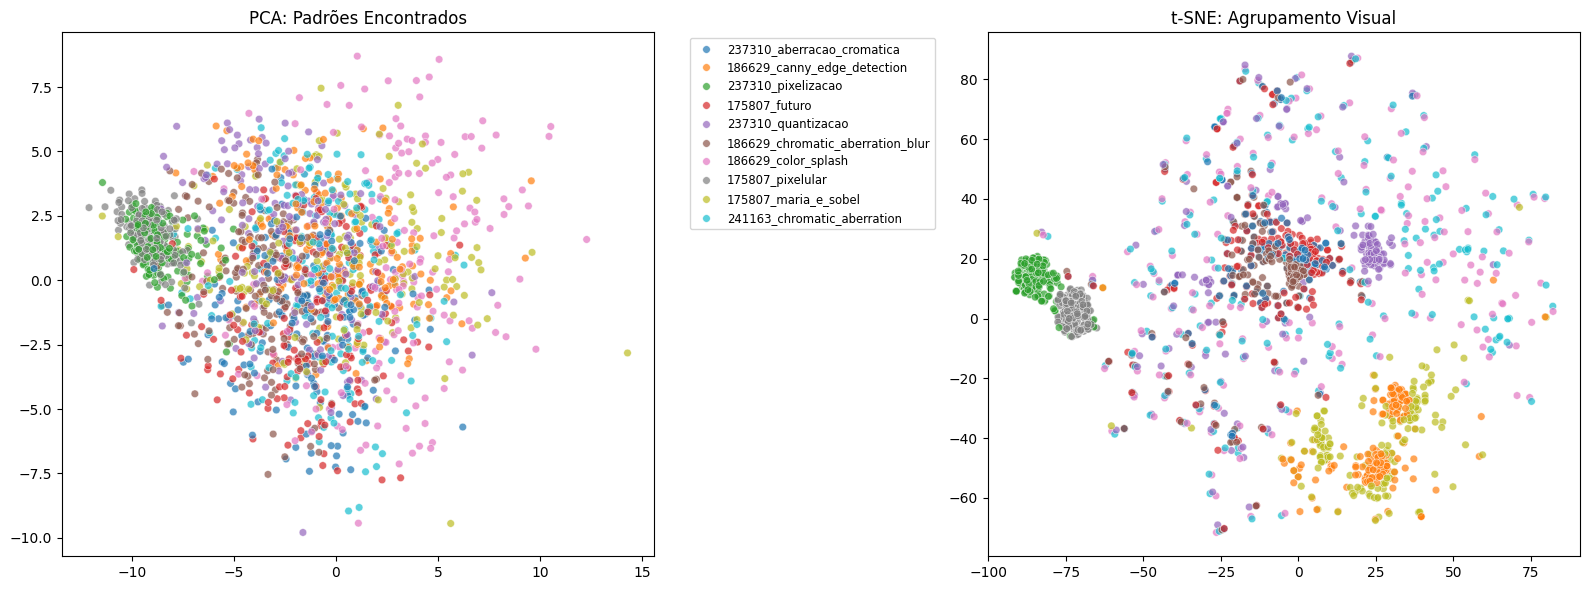

In [9]:
# Para não termos 42 cores misturadas, vamos focar nos 10 primeiros efeitos
efeitos_para_plotar = 10
mask = y_subset < efeitos_para_plotar

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Define uma paleta de cores bonita do Seaborn
palette = sns.color_palette("tab10", efeitos_para_plotar)
nomes_efeitos = classes[:efeitos_para_plotar]

# Plot PCA
sns.scatterplot(x=X_pca[mask, 0], y=X_pca[mask, 1], hue=[nomes_efeitos[i] for i in y_subset[mask]],
                palette=palette, ax=ax1, s=30, alpha=0.7)
ax1.set_title("PCA: Padrões Encontrados")
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')

# Plot t-SNE
sns.scatterplot(x=X_tsne[mask, 0], y=X_tsne[mask, 1], hue=[nomes_efeitos[i] for i in y_subset[mask]],
                palette=palette, ax=ax2, s=30, alpha=0.7)
ax2.set_title("t-SNE: Agrupamento Visual")
ax2.get_legend().remove() # Remove a legenda duplicada

plt.tight_layout()
plt.show()

Selecionando 10 das classes para demonstrar o desempenho de cada algorítmo em, através da redução de dimensionalidade, separar os dados. Esses algorítmos em si não estão tentando agrupar os dados, mas o fazem ao mapear indivíduos parecidos em regiões parecidas.

O Desempenho observado do PCA é muito ruim se comparado ao t-SNE. Enquanto usando PCA podemos no máximo observar a região que dados do grupo em verde estão próximos, o t-SNE consegue separar de forma satisfatória algum dos grupos, nos permitindo separar claramente os grupos de efeitos.

### Clusterização
Outra abordagem pode ser obtida ao usar algoritmos de Clusterização - Agrupamento. A missão deles é definir como rotular os dados. Vamos escolher 2 algorítmos de clusterização e estudar como eles se comportam ao ter contato com os nossos dados.

### K-Means

O K-Means é um algorítmo de otimização iterativa. Ao definirmos K centros ou clusters, aleatóriamente. Atribuimos cada ponto do dataset ao K mais próximo, recalculamos a posição do K de acordo com os pontos do dataset.

O papel do K-Means não é desenhar os pontos na tela e sim definir que grupo de dados esse dado faz parte. Por isso para demonstrar os dados vamos usar o plot do t-SNE, agora colorido pelo K-Means.

### UMAP - Uniform Manifold Approximation

Para dividir os dados o UMAP parte de algumas suposições:

1. Os dados devem estar distribuídos uniformemente em um Manifold de alta dimensionalidade

2. Não há pontos vazios - Localmente conectado

3. Não há distorções no espaço (caso do t-SNE)

Para respeitar as suposições ele se divide em duas etapas: Construção do Grafo e Otimização do Layout.

Depois de forçar que as condições sejam atingidas através da construção do grafo, o algoritmo separa ou agrupa dados onde a partir de uma certa distância é definido se um indivíduo deve se afastar ou aproximar.



In [13]:
print("Calculando UMAP")
# UMAP
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='euclidean', random_state=42)
X_umap = reducer.fit_transform(X_subset) # Usando o mesmo subconjunto do t-SNE

print("Rodando K-Means")
# Vamos pedir para ele achar 42 grupos (pois sabemos que temos 42 classes reais)
# Rodamos em cima do PCA para evitar a "maldição da dimensionalidade" dos 512 números
kmeans = KMeans(n_clusters=len(classes), random_state=42, n_init='auto')
clusters_previstos = kmeans.fit_predict(X_subset)



Calculando UMAP


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Rodando K-Means


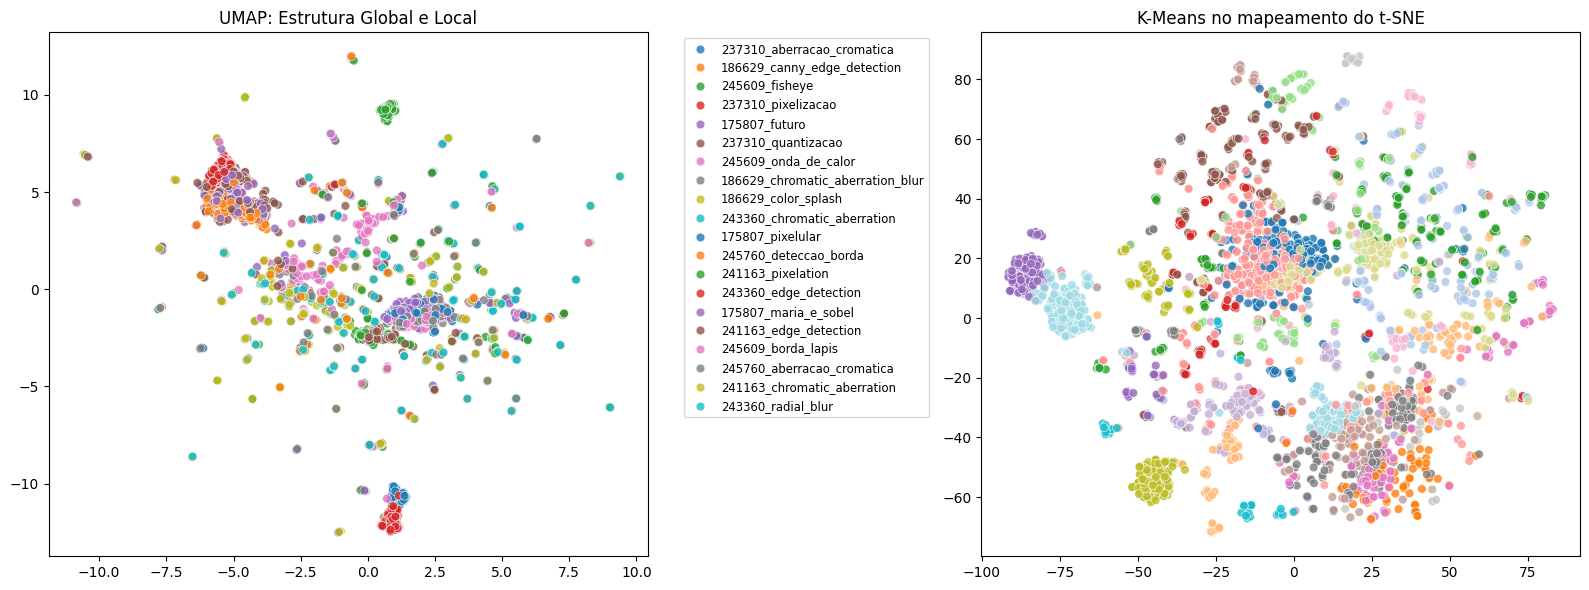

In [16]:
# Vamos visualizar os resultados
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: O poder do UMAP com as cores REAIS
sns.scatterplot(x=X_umap[mask, 0], y=X_umap[mask, 1],
                hue=[nomes_efeitos[i] for i in y_subset[mask]],
                palette=palette, ax=ax1, s=40, alpha=0.8)
ax1.set_title("UMAP: Estrutura Global e Local")
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')

# Plot 2: t-SNE colorido pelo K-MEANS
# Usamos o t-SNE (ou UMAP) apenas como "tela" e colorimos com os clusters do KMeans
sns.scatterplot(x=X_tsne[mask, 0], y=X_tsne[mask, 1],
                hue=clusters_previstos[mask],
                palette="tab20", ax=ax2, s=40, alpha=0.8, legend=False)
ax2.set_title("K-Means no mapeamento do t-SNE")

plt.tight_layout()
plt.show()

Por fim vamos analisar quantitativamente os algorítmos:

ARI compara quantos grupos o K-Means inventou com as pastas originais.

Silhouette Score mede o quão densas e separadas são as ilhas

In [18]:
import time
import pandas as pd
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.cluster import KMeans


resultados = []

# 1. Avaliando PCA
inicio = time.time()
pca_teste = PCA(n_components=2).fit_transform(X_subset)
tempo_pca = time.time() - inicio
resultados.append({'Algoritmo': 'PCA', 'Tempo (segundos)': tempo_pca, 'Dados': pca_teste})

# 2. Avaliando t-SNE
inicio = time.time()
tsne_teste = TSNE(n_components=2, random_state=42).fit_transform(X_subset)
tempo_tsne = time.time() - inicio
resultados.append({'Algoritmo': 't-SNE', 'Tempo (segundos)': tempo_tsne, 'Dados': tsne_teste})

# 3. Avaliando UMAP
inicio = time.time()
umap_teste = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42).fit_transform(X_subset)
tempo_umap = time.time() - inicio
resultados.append({'Algoritmo': 'UMAP', 'Tempo (segundos)': tempo_umap, 'Dados': umap_teste})

# Quantos clusters reais temos na amostra?
n_clusters_reais = len(np.unique(y_subset))

metricas = []

for res in resultados:
    nome = res['Algoritmo']
    dados_2d = res['Dados']
    tempo = res['Tempo (segundos)']

    # Roda o K-Means no resultado 2D deste algoritmo
    kmeans = KMeans(n_clusters=n_clusters_reais, random_state=42, n_init='auto')
    clusters_gerados = kmeans.fit_predict(dados_2d)

    # Calcula Silhouette (Quão bem separadas estão as bolinhas visualmente)
    silhouette = silhouette_score(dados_2d, clusters_gerados)

    # Calcula ARI (O quanto os grupos cegos batem com as classes reais)
    ari = adjusted_rand_score(y_subset, clusters_gerados)

    metricas.append({
        'Redutor': nome,
        'Tempo de Execução (s)': round(tempo, 4),
        'Silhouette Score (Visão)': round(silhouette, 4),
        'ARI (Acerto Real)': round(ari, 4)
    })

# Cria uma tabela bonita para mostrar no relatório
df_metricas = pd.DataFrame(metricas)
df_metricas.set_index('Redutor', inplace=True)

print("TABELA DE RESULTADOS")
display(df_metricas)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


TABELA DE RESULTADOS


,Tempo de Execução (s),Silhouette Score (Visão),ARI (Acerto Real)
Redutor,,,
PCA,0.0826,0.3333,0.0662
t-SNE,75.0129,0.4122,0.2130
UMAP,13.2615,0.4702,0.2087


Para 42 classes, os dados do Silhoutte Score estão até bons para os 3 casos.

Apesar de que no PCA a nuvem de dados tornava quase impossível separar os dados. Enquanto isso o K-Means performou muito mal,  principalmente se posto sobre o PCA.

Isso pode ser explicado também pela natueza do Dataset, labels diferentes para os mesmos efeitos: Mais de uma pessoa pode ter implementado aberração cromática por exemplo.

# Classificação - Algoritmos Supervisionados

Nossa missão agora é classificar as fotos por tipo de efeito. Ao encontrar padrões nos dados devemos separá-los em rótulos que carregam os mesmos nomes das pastas.

### KNN
Vamos começar os exercícios de classificação desses efeitos. Usando KNN, devemos ajustar os hiperparametros, nesse caso, o número de vizinhos para achar um desempenho ótimo. Vamos deixar um algoritmo escolher entre 2 e 20 vizinhos.

In [27]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.model_selection import train_test_split

# Divide os dados que extraímos lá atrás (80% para treino, 20% para teste)
X_train, X_test, y_train, y_test = train_test_split(X_subset, y_subset, test_size=0.2, random_state=42)
print("Iniciando a varredura para encontrar o número de vizinhos (K) ideal")

k_valores = range(2, 21) # Testa do K=2 até o K=20
acuracias = []
melhor_k = 2
melhor_acc = 0

# 1. O Loop de Busca (Hyperparameter Tuning)
for k in k_valores:
    knn_temp = KNeighborsClassifier(n_neighbors=k, weights='distance')
    knn_temp.fit(X_train, y_train)

    y_pred_temp = knn_temp.predict(X_test)
    acc_temp = accuracy_score(y_test, y_pred_temp)
    acuracias.append(acc_temp)

    # Atualiza se esse K for o melhor até agora
    if acc_temp > melhor_acc:
        melhor_acc = acc_temp
        melhor_k = k

print(f"K escolhido foi: {melhor_k} (Acurácia: {melhor_acc*100:.2f}%)\n")

print(f"Treinando com o melhor k")

knn_best = KNeighborsClassifier(n_neighbors=melhor_k, weights='distance')
knn_best.fit(X_train, y_train)
y_pred_best = knn_best.predict(X_test)
acc_final = accuracy_score(y_test, y_pred_best)


print(f"RESULTADOS:")
print(f"Acurácia do KNN (Baseline):      {acc_final * 100:.2f}%\n")

print("Relatório de Classificação Detalhado do KNN Otimizado:")
print(classification_report(y_test, y_pred_best, target_names=classes, zero_division=0))

Iniciando a varredura para encontrar o número de vizinhos (K) ideal
K escolhido foi: 19 (Acurácia: 52.60%)

Treinando com o melhor k
RESULTADOS:
Acurácia do KNN (Baseline):      52.60%

Relatório de Classificação Detalhado do KNN Otimizado:
                                                     precision    recall  f1-score   support

                                      175807_futuro       0.86      0.80      0.83        40
                               175807_maria_e_sobel       0.72      0.41      0.52        44
                                   175807_pixelular       0.85      1.00      0.92        50
                        186629_canny_edge_detection       0.64      0.94      0.76        51
                   186629_chromatic_aberration_blur       0.71      0.82      0.76        33
                                186629_color_splash       0.00      0.00      0.00        33
                         237310_aberracao_cromatica       0.58      0.63      0.60        35
              

Gerando os gráficos finais...


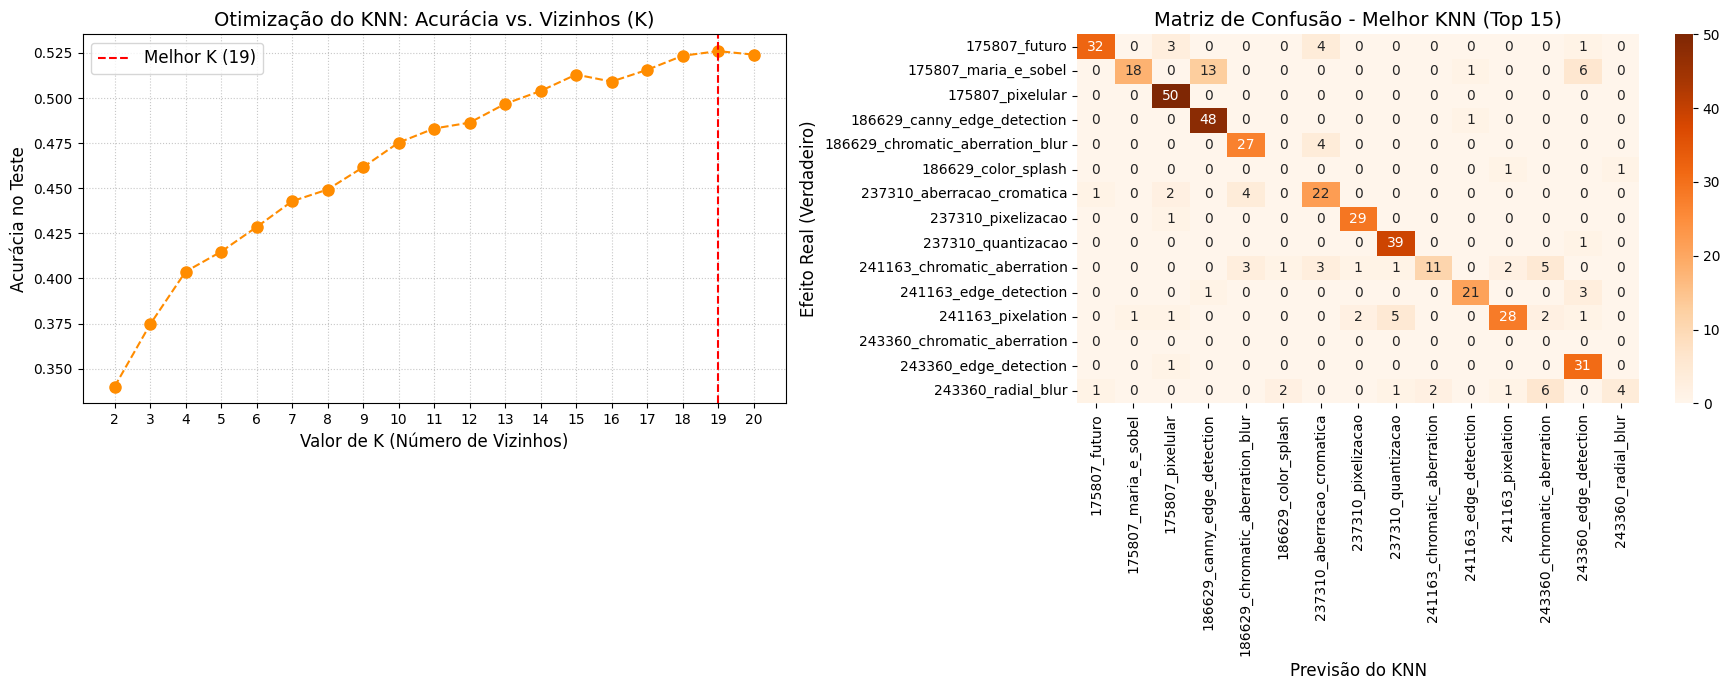

In [29]:
print("Gerando os gráficos finais...")

# Cria uma figura com 2 gráficos lado a lado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Gráfico 1: A Curva do K (Lado Esquerdo)
ax1.plot(k_valores, acuracias, marker='o', linestyle='dashed', color='darkorange', markersize=8)
ax1.set_title('Otimização do KNN: Acurácia vs. Vizinhos (K)', fontsize=14)
ax1.set_xlabel('Valor de K (Número de Vizinhos)', fontsize=12)
ax1.set_ylabel('Acurácia no Teste', fontsize=12)
ax1.set_xticks(k_valores)
ax1.axvline(x=melhor_k, color='red', linestyle='--', label=f'Melhor K ({melhor_k})')
ax1.legend(fontsize=12)
ax1.grid(True, linestyle=':', alpha=0.7)

# Gráfico 2: A Matriz de Confusão Laranja (Lado Direito)
cm_knn = confusion_matrix(y_test, y_pred_best)
top_n = 15
cm_knn_subset = cm_knn[:top_n, :top_n]

sns.heatmap(cm_knn_subset, annot=True, fmt='d', cmap='Oranges',
            xticklabels=classes[:top_n], yticklabels=classes[:top_n], ax=ax2)
ax2.set_title(f'Matriz de Confusão - Melhor KNN (Top {top_n})', fontsize=14)
ax2.set_ylabel('Efeito Real (Verdadeiro)', fontsize=12)
ax2.set_xlabel('Previsão do KNN', fontsize=12)
ax2.tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

### Análise dos resultados do KNN

Ao usar uma técnica simples de busca linear para achar um bom novo valor para nosso número de vizinhos, conseguimos ver um ganho significativo na acuráciado nosso modelo. Apesar de simples é importante notar que o KNN foi suficiente para classificar esse algorítmo muito bem na maior parte dos casos.
Os casos com maior erro envolvem principalmente os problemas que o próprio dataset traz que já foram comentados.   

Com 19 vizinhos a acurácia no teste chegou a 0.525. Talvez com mais vizinhos a Acurácia e outras métricas como f1-score melhorassem, entretanto é possível notar que a curva está saturando aos poucos.

### Classificação usando Deep Learning
Vamos seguir em frente e sem muito se trabalhar, vamos aplicar uma MLP para fazer a classificação. Vamos então comparar os resultados e principalmente levar em consideração o custo de cada técnica aplicada.

In [33]:
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


# 80% treino 20 % validação
# O parâmetro 'stratify=y_labels' garante que todas as classes tenham representantes no teste
X_train, X_test, y_train, y_test = train_test_split(
    X_features, y_labels, test_size=0.2, random_state=42, stratify=y_labels
)

# Convertendo de volta para Tensores do PyTorch
train_dataset = TensorDataset(torch.tensor(X_train), torch.tensor(y_train))
test_dataset = TensorDataset(torch.tensor(X_test), torch.tensor(y_test))

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Construindo a nossa Rede Neural
class AdvancedClassifier(nn.Module):
    def __init__(self, input_size, num_classes):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.BatchNorm1d(256), # Estabiliza o aprendizado
            nn.ReLU(),
            nn.Dropout(0.4),
            # Previne Overfitting (desliga 40% dos neurônios)
            # tornando menos pesada a rede e priorizando os neurônios mais competentes

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, num_classes) # Saída para os 42 efeitos
        )

    def forward(self, x):
        return self.network(x)

# Instancia o modelo e manda para a GPU
model = AdvancedClassifier(input_size=512, num_classes=len(classes)).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Escolhemos 30 épocas para treinar
epochs = 30
print(f"Iniciando o treinamento por {epochs} épocas")

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # Validação no Teste
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += targets.size(0)
            correct += (predicted == targets).sum().item()

    acc = 100 * correct / total

    # Mostra o progresso a cada 5 épocas
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Época [{epoch+1:02d}/{epochs}] | Loss Treino: {running_loss/len(train_loader):.4f} | Acurácia Teste: {acc:.2f}%")
print("Treinamento Concluído!")


Iniciando o treinamento por 30 épocas
Época [01/30] | Loss Treino: 2.5724 | Acurácia Teste: 60.60%
Época [05/30] | Loss Treino: 0.7593 | Acurácia Teste: 77.18%
Época [10/30] | Loss Treino: 0.5234 | Acurácia Teste: 78.09%
Época [15/30] | Loss Treino: 0.4653 | Acurácia Teste: 78.22%
Época [20/30] | Loss Treino: 0.4494 | Acurácia Teste: 77.83%
Época [25/30] | Loss Treino: 0.4010 | Acurácia Teste: 77.89%
Época [30/30] | Loss Treino: 0.3614 | Acurácia Teste: 79.39%
Treinamento Concluído!


Gerando as análises quantitativas...


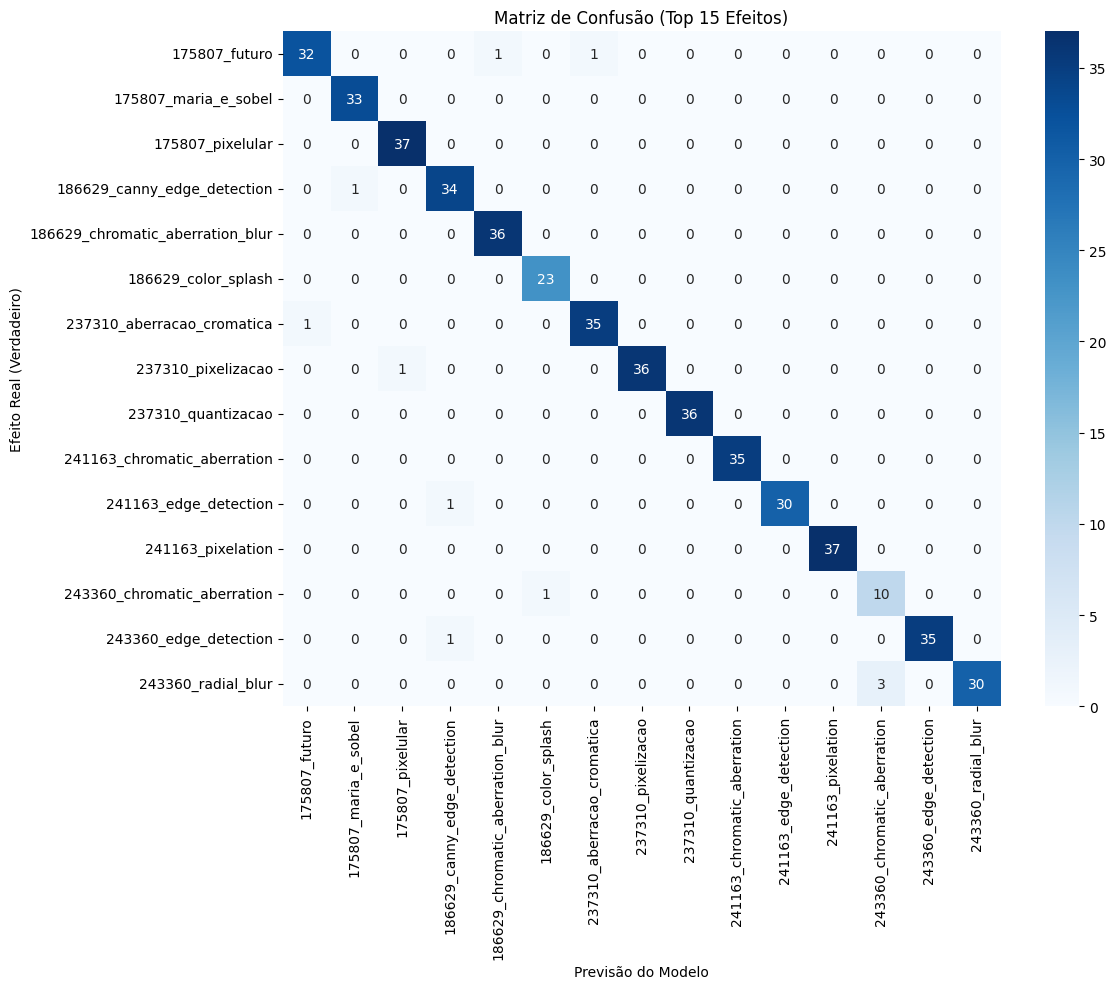

Relatório de Classificação Detalhado:
                                                     precision    recall  f1-score   support

                                      175807_futuro       0.94      0.86      0.90        37
                               175807_maria_e_sobel       0.80      0.89      0.85        37
                                   175807_pixelular       0.97      1.00      0.99        37
                        186629_canny_edge_detection       0.94      0.92      0.93        37
                   186629_chromatic_aberration_blur       0.95      1.00      0.97        36
                                186629_color_splash       0.55      0.62      0.58        37
                         237310_aberracao_cromatica       0.97      0.97      0.97        36
                                 237310_pixelizacao       1.00      0.97      0.99        37
                                 237310_quantizacao       0.97      1.00      0.99        36
                        241163_

In [34]:
print("Gerando as análises quantitativas...")

# Pega todas as previsões do conjunto de teste de uma vez
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(targets.numpy())
# Para a visualização não virar um borrão com 42 classes,
# vamos plotar a Matriz de Confusão das 15 classes mais frequentes/importantes
top_n = 15
fig, ax = plt.subplots(figsize=(12, 10))
cm = confusion_matrix(all_targets, all_preds)

# Recorta a matriz para mostrar só as N primeiras classes
cm_subset = cm[:top_n, :top_n]
sns.heatmap(cm_subset, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes[:top_n], yticklabels=classes[:top_n], ax=ax)

plt.ylabel('Efeito Real (Verdadeiro)')
plt.xlabel('Previsão do Modelo')
plt.title(f'Matriz de Confusão (Top {top_n} Efeitos)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Imprime o relatório detalhado
print("Relatório de Classificação Detalhado:")
# Usamos zero_division=0 para evitar warnings caso o modelo não preveja alguma classe
print(classification_report(all_targets, all_preds, target_names=classes, zero_division=0))

### Comparação entre os modelos

Usando um classificador gerado a partir de uma MLP chegamos a quase 80% de acurácia vs 53% do KNN. Querendo ou não o KNN confia somente na distância entre pontos. Isso é refletido na matriz de decisão, que não mosta quase nenhum desvio exceto nos casos em que mais de uma pessoa implementou efeitos muito parecidos.   
Como nossas imagens agora tem 512 dimensões, não é possível bater uma MLP. Ao treinar a matriz de pesos, estamos treinando extratores de atributos extremamente competentes para realizar essas tarefas.    
Ao se apoiar em técnicas muito mais sofisticadas como o gradiente descendente e funções de ativação não-lineares — a MLP consegue filtrar o ruído dimensional e aprender as fronteiras complexas que o KNN, limitado pela rigidez da métrica euclidiana, acaba por ignorar.